## CNN Baseline Walkthrough

Use this notebook as a guided tour of the baseline convolutional model pipeline: set up the environment, configure the dataset, and train/evaluate a CNN without altering the underlying implementation.

### Notebook setup
Load project modules and enable autoreload so edits in `src/` are picked up without restarting the kernel.

In [1]:
# Auto-reload local modules during iterative development
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
# Ensure the src/ directory is on the Python path for relative imports
sys.path.append(str(Path.cwd().parent))

# Project utilities
from utils import *
from utils_visualisation import *
from models import *
from engine import *
from Data_Handler import ClimbingDataset

# PyTorch + torchmetrics helpers
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

# Image filters and model inspection
import kornia.filters as KF
from torchinfo import summary

/home/fillies/Documents/moon/kilter/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Hyperparameters
These values configure both the dataset preprocessing and the CNN architecture. Adjust them here before re-running the notebook:
- `blur_kernel_size`, `blur_sigma`: smoothing applied to input hold maps.
- `batch_size`: samples per gradient step.
- `hidden_units_CNN`: number of convolutional feature maps.
- `hidden_units_classifier`: width of the fully-connected head.
- `lr`, `weight_decay`: optimizer settings shared across experiments.

In [2]:
# Core training and preprocessing hyperparameters
blur_kernel_size = 3
blur_sigma = 1.0
batch_size = 32
hidden_units_CNN = 16
hidden_units_classifier = 16
lr = 1e-4
weight_decay = 1e-4

### Configure dataset
Create a `ClimbingDataset` with a light Gaussian blur and a focused set of difficulty grades.

#### ClimbingDataset arguments
- `board_names`: which Kilter board layouts to load from the SQLite export.
- `map`: compresses sparse (x, y) coordinates into contiguous indices for CNN kernels.
- `transform`: optional Kornia transform applied to each route tensor (here, a mild blur).
- `label_filter`: select specific grade indices to keep the task scoped.
- `max_samples`: upper bound on routes loaded to keep experimentation responsive.

In [3]:
# Slight blur to smooth binary hold activations
transform = KF.GaussianBlur2d(
    kernel_size=(blur_kernel_size, blur_kernel_size),
    sigma=(blur_sigma, blur_sigma),
    border_type="constant",
)

# Load a single board configuration and a subset of grades for faster iteration
climbing_DB = ClimbingDataset(
    board_names=["12 x 12 with kickboard Square"],
    map=True,  # remap coordinates to a dense grid
    transform=transform,  # optional per-sample preprocessing
    label_filter=[5, 14],  # e.g. V4 and V11 indices
    max_samples=12000,  # cap dataset size for notebook runs
)
num_classes = climbing_DB.num_classes
num_features = climbing_DB.num_features

print(f"Number of classes: {num_classes}")
print(f"Number of features: {num_features}")

Number of classes: 21
Number of features: 4


### Inspect a sample route
Peek at a single example to confirm tensor shapes and visualise the holds highlighted.

Total routes available: 4,472
Feature tensor shape: torch.Size([4, 35, 35]) | One-hot label shape: torch.Size([21])


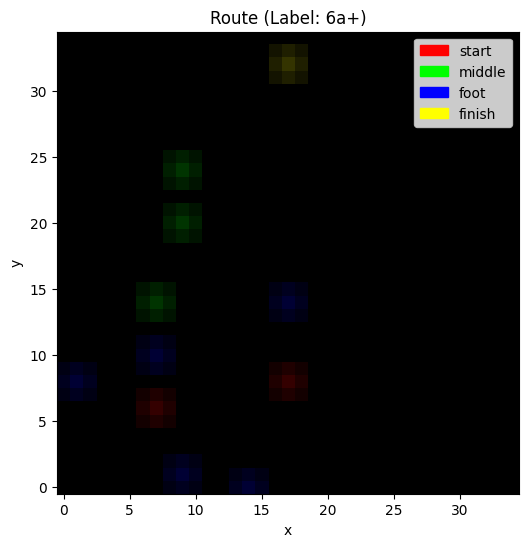

In [4]:
print(f"Total routes available: {len(climbing_DB):,}")

# Grab a representative example for visual inspection
X, y = climbing_DB[15]
print(f"Feature tensor shape: {X.shape} | One-hot label shape: {y.shape}")
plot_route(X, torch.argmax(y))

### Build train/test splits
Create deterministic splits and wrap them in `DataLoader` objects.

In [5]:
# Deterministic 80/20 split for reproducibility
train_size = int(0.8 * len(climbing_DB))
test_size = len(climbing_DB) - train_size
train_dataset, test_dataset = random_split(
    climbing_DB,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42),
)

# DataLoaders for stochastic training (enable pinned memory for optional GPU runs)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

print(f"Train samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")

Train samples: 3577, Test samples: 895


### Dataset overview
Estimate memory consumption and visualise the grade distribution across splits.

Approx dataset tensor size: 88.03 MB
Train distribution:
  Class 6a+: 1523.0 (42.6%)
  Class 7c: 2054.0 (57.4%)

Test distribution:
  Class 6a+: 379.0 (42.3%)
  Class 7c: 516.0 (57.7%)


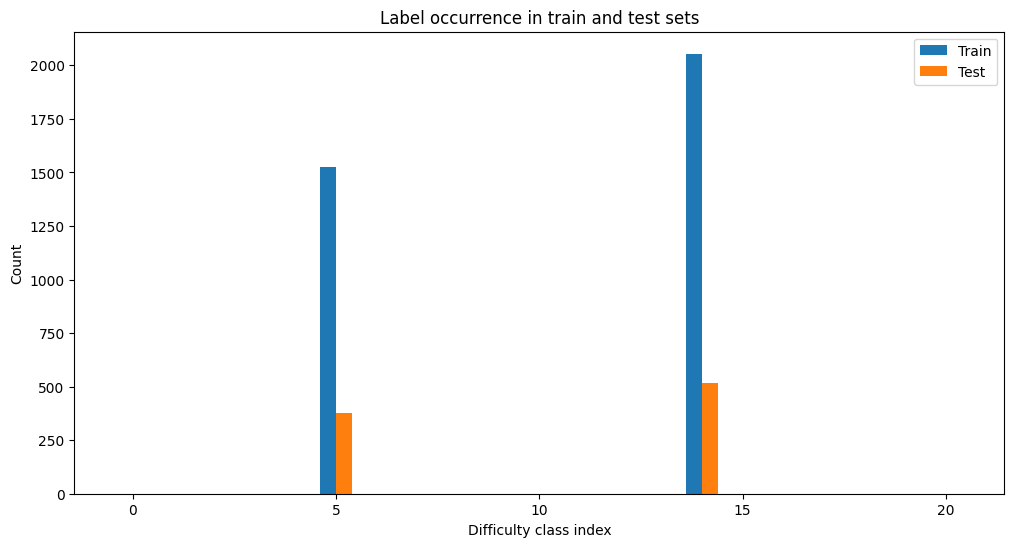

In [6]:
# Estimate tensor footprint across train/test splits
total_bytes = 0
for dataset in (train_dataset, test_dataset):
    for data, target in dataset:
        if isinstance(data, torch.Tensor):
            total_bytes += data.element_size() * data.nelement()
        if isinstance(target, torch.Tensor):
            total_bytes += target.element_size() * target.nelement()
print(f"Approx dataset tensor size: {total_bytes / 1e6:.2f} MB")

# Visualise grade coverage to ensure both splits remain balanced
plot_label_distribution(train_dataset, test_dataset, num_classes=climbing_DB.num_classes)

### Runtime environment
Check the torch version and the device that will be used for training.

In [7]:
print(f"Using torch {torch.__version__}")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Training on device: {device}")

Using torch 2.8.0+cu128
Training on device: cpu


### Configure model and metrics
`shallowCNN` is one option within the `CNN_MODEL_REGISTRY` (see `src/models.py`). Swap the key to explore variants while keeping the shared loss and accuracy helpers.

In [8]:
loss_fn = torch.nn.CrossEntropyLoss()
acc_fn = Multiclass_accuracy()  # wrapper around torchmetrics to report grade accuracy

# Instantiate the selected CNN architecture (switch to other registry keys as needed)
shallow_model = shallowCNN(
    input_shape=num_features,
    hidden_units_CNN=hidden_units_CNN,
    hidden_units_classifier=hidden_units_classifier,
    output_shape=num_classes,
).to(device)
optimizer_shallow = optim.Adam(shallow_model.parameters(), lr=lr, weight_decay=weight_decay)

# Inspect parameter count and expected input shape
summary(model=shallow_model, input_size=(1, 4, 35, 35))

Layer (type:depth-idx)                   Output Shape              Param #
shallowCNN                               [1, 21]                   --
├─Sequential: 1-1                        [1, 16, 35, 35]           --
│    └─Conv2d: 2-1                       [1, 16, 35, 35]           592
│    └─ReLU: 2-2                         [1, 16, 35, 35]           --
│    └─BatchNorm2d: 2-3                  [1, 16, 35, 35]           32
│    └─Conv2d: 2-4                       [1, 16, 35, 35]           2,320
│    └─ReLU: 2-5                         [1, 16, 35, 35]           --
│    └─BatchNorm2d: 2-6                  [1, 16, 35, 35]           32
├─Sequential: 1-2                        [1, 21]                   --
│    └─AdaptiveAvgPool2d: 2-7            [1, 16, 1, 1]             --
│    └─Flatten: 2-8                      [1, 16]                   --
│    └─Linear: 2-9                       [1, 16]                   272
│    └─ReLU: 2-10                        [1, 16]                   --
│    └─Dro

### Train the model
Fit the network using the shared `train_model` helper.

In [9]:
trained_model, history = train_model(
    model=shallow_model,
    train_loader=train_loader,
    test_loader=test_loader,
    loss_fn=loss_fn,
    optimizer=optimizer_shallow,
    acc_fn=acc_fn,
    device=device,
    epochs=100,  # baseline uses 100 epochs
    patience=15,  # early-stopping patience
)

/home/fillies/Documents/moon/kilter/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



Epoch 0000 | Train loss: 3.00649 | Train acc: 0.00195 | Test loss: 2.96612 | Test acc: 0.00670
Timing: total 3.980 s | train 3.261 s | eval 0.719 s

Epoch 0001 | Train loss: 2.93661 | Train acc: 0.15472 | Test loss: 2.89568 | Test acc: 0.38317
Timing: total 2.350 s | train 1.865 s | eval 0.485 s

Epoch 0002 | Train loss: 2.85091 | Train acc: 0.42405 | Test loss: 2.79407 | Test acc: 0.42339
Timing: total 2.325 s | train 1.799 s | eval 0.525 s

Epoch 0003 | Train loss: 2.72259 | Train acc: 0.42596 | Test loss: 2.63130 | Test acc: 0.42339
Timing: total 2.520 s | train 2.010 s | eval 0.510 s

Epoch 0004 | Train loss: 2.51910 | Train acc: 0.42596 | Test loss: 2.35378 | Test acc: 0.42339
Timing: total 2.335 s | train 1.885 s | eval 0.450 s

Epoch 0005 | Train loss: 2.22756 | Train acc: 0.42616 | Test loss: 2.10330 | Test acc: 0.42339
Timing: total 2.797 s | train 2.285 s | eval 0.512 s

Epoch 0006 | Train loss: 1.85762 | Train acc: 0.42700 | Test loss: 1.57693 | Test acc: 0.49057
Timing: to

### Evaluate predictions
Review how the trained model distributes probabilities across the grade classes.


📊 Distributions for shallowCNN:
True labels:
  Class 5: 379 (42.3%)
  Class 14: 516 (57.7%)

Predicted labels:
  Class 5: 333 (37.2%)
  Class 14: 562 (62.8%)

✅ Accuracy (overall): 85.47% (765/895)
ℹ️  Accuracy via acc_fn (avg over batches): 85.47%


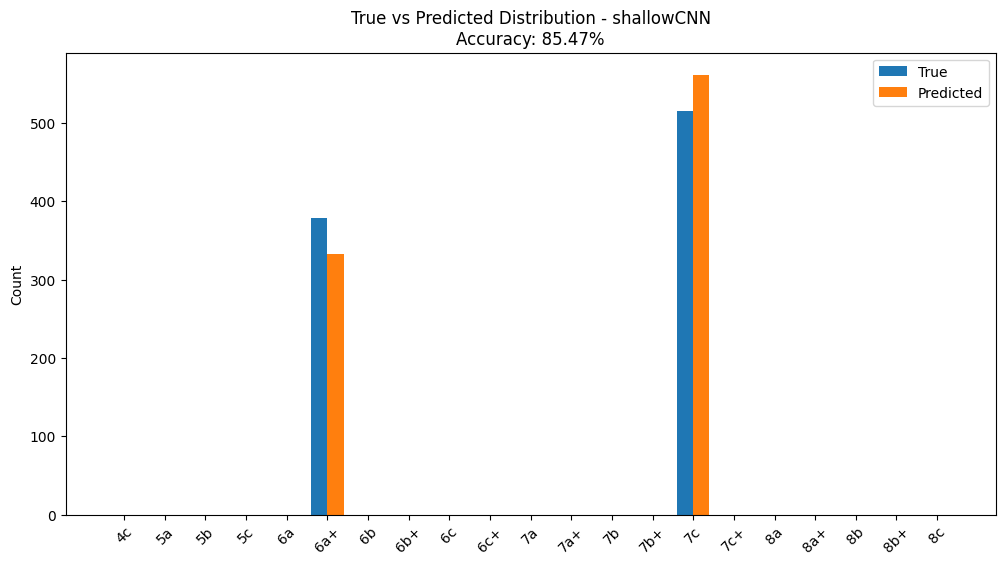

In [10]:
plot_prediction_distribution(
    model=shallow_model,
    test_loader=test_loader,
    num_classes=num_classes,
    model_name=shallow_model.__class__.__name__,
    acc_fn=acc_fn,
    device=device,
)

### Plot training history
Visualise loss and accuracy across epochs.

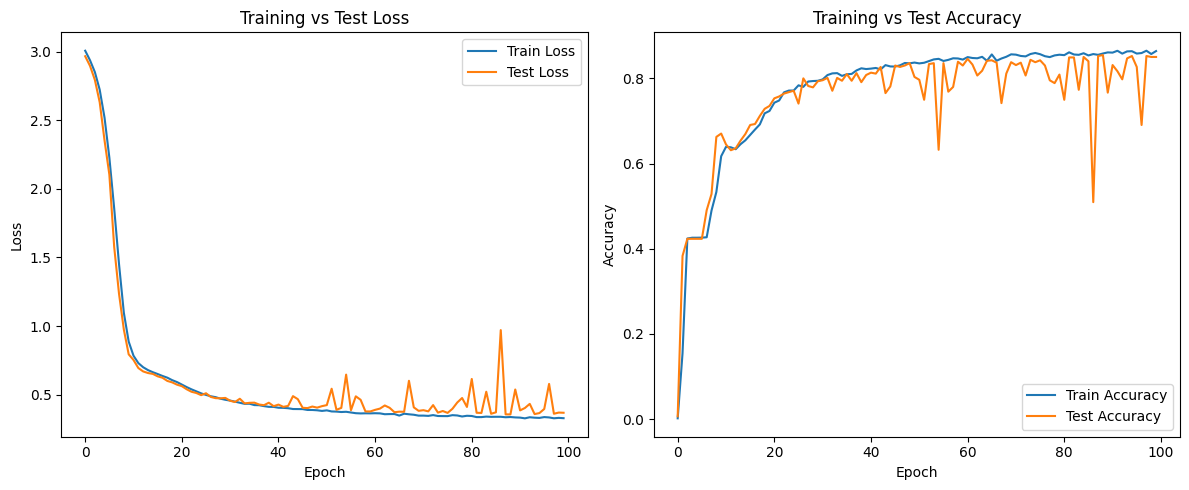

In [11]:
plot_training_history(history)